## Импорт библиотек

In [1]:
import warnings
warnings.filterwarnings('ignore')

import os
import gc
import json
import time
import psutil
import pickle

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from collections import Counter, defaultdict

from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score

from lightgbm import LGBMClassifier
from xgboost import XGBClassifier


## Динамика точности модели в зависимости от количества признаков при различных пороговых значениях RFECV

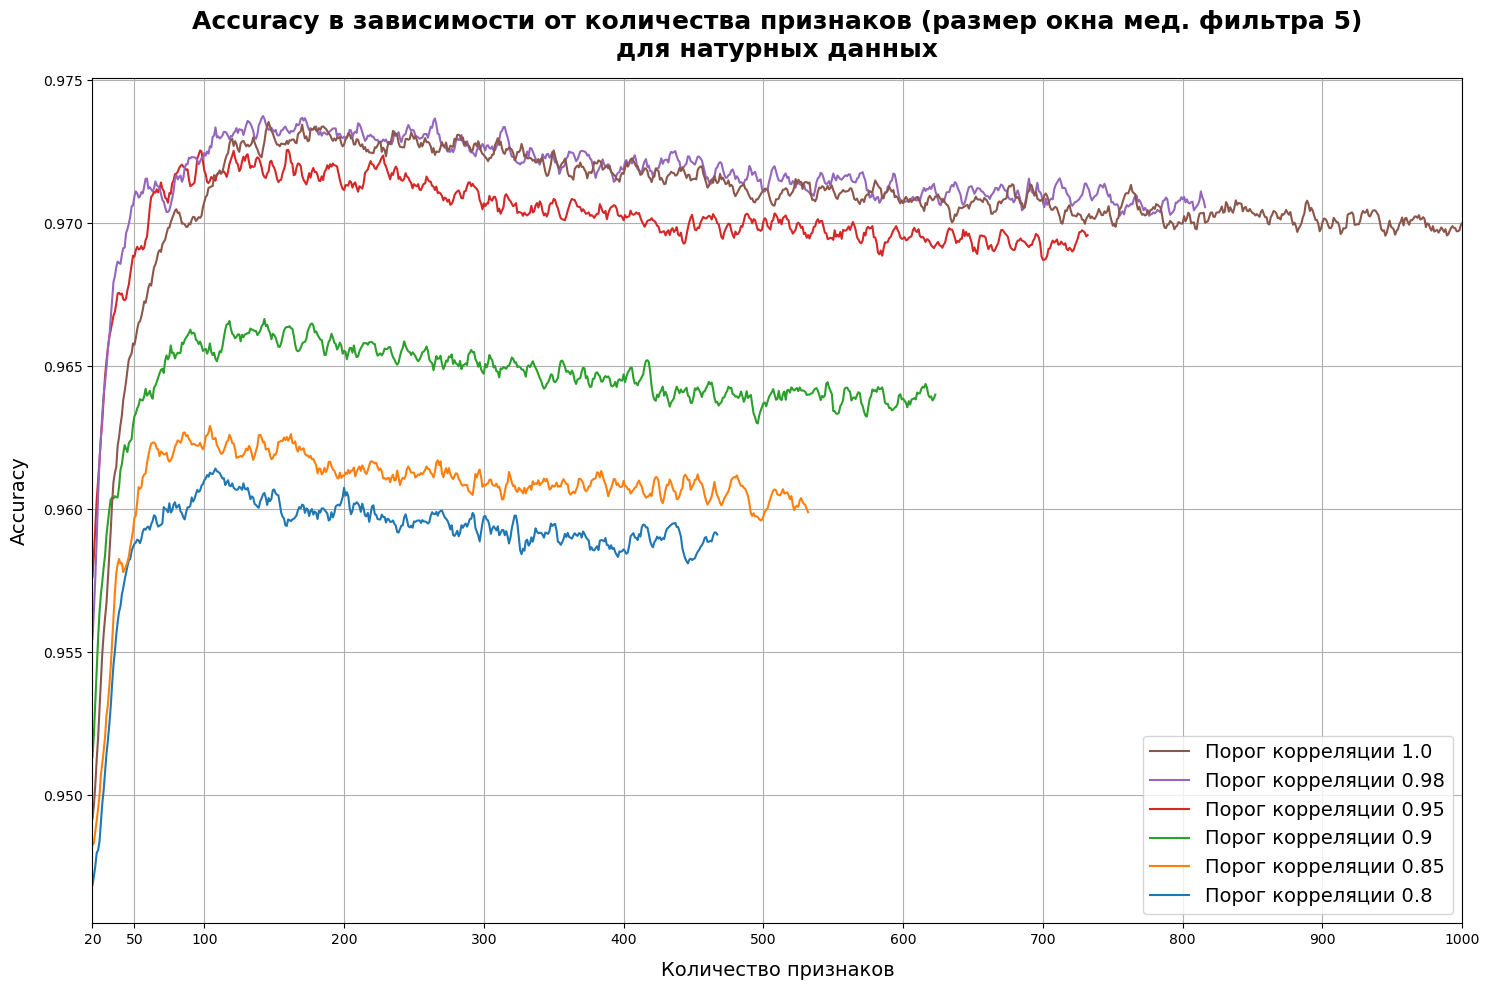

In [22]:
thresholds = [0.8, 0.85, 0.9, 0.95, 0.98, 1]

def moving_average(data, median_window_size):
    
    if median_window_size % 2 == 0:
        raise ValueError("Размер окна должен быть нечетным")
    
    data = np.array(data)
    half_window = median_window_size // 2
    
    # Дополнение массива
    padded_data = np.pad(data, (half_window, half_window), mode='edge')

    # Ядро для свертки
    kernel = np.ones(median_window_size) / median_window_size
    
    # Применение свертки
    result = np.convolve(padded_data, kernel, mode='valid')
    
    return result

# Параметры
a = 20                  # a э [1; inf]
b = 1000                  # b э [a+1; inf]
median_window_size = 5  # Размер окна для сглаживания (нечетный)

rfecv_results_dir = 'DATA/rfecv_results'

json_file_names = [name for name in os.listdir(rfecv_results_dir) if "json" in name]
rfecv_results_list = []

for name in json_file_names: 
    with open(rf'{rfecv_results_dir}\{name}', 'r', encoding='utf-8') as file:
        rfecv_results_list.append(json.load(file))
        
a = max(1, a)

plt.figure(figsize=(15, 10))

for res, threshold in zip(rfecv_results_list, thresholds):
    new_a = min(len(res['mean_test_score']), a)
    new_b = min(len(res['mean_test_score']), b)
    
    smoothed_res = moving_average(res['mean_test_score'][new_a-1:new_b], median_window_size)
    x_range = range(new_a, new_b+1)
    
    plt.plot(x_range, 
             smoothed_res,
             label=f'Порог корреляции {float(threshold)}')
    
plt.xlim(x_range.start, x_range.stop - 1)
plt.xticks(np.arange(new_a, new_b+1, 30))  # шаг 50
plt.xticks([20, 50, 100, 200, 300, 400, 500, 600, 700, 800, 900, 1000])  # шаг 50

plt.grid()
plt.xlabel("Количество признаков",
           fontsize=14, 
           fontweight='medium', 
           labelpad=10)

plt.ylabel("Accuracy",
           fontsize=14, 
           fontweight='medium', 
           labelpad=10)

plt.title(f"Accuracy в зависимости от количества признаков (размер окна мед. фильтра {median_window_size})\nдля натурных данных", 
          fontweight='demibold', 
          fontsize=18, 
          pad=15)

handles, labels = plt.gca().get_legend_handles_labels()
plt.legend(handles[::-1], labels[::-1], loc='lower right', fontsize=14)
plt.tight_layout()

plt.savefig('APPLICATIONS/Accuracy в зависимости от количества признаков.png', dpi=400, bbox_inches='tight')
plt.show()


**Оптимальным является порог 0.98 при количестве признаков 40-70**

## Более взвешенная оценка точности модели в выбранном диапазоне количества признаков

In [21]:
# Загрузка результатов RFECV
with open("DATA/rfecv_results/rfecv_threshold_0.98.json", 'r') as f:
    file = json.load(f)

num_of_features_start = 40
num_of_features_end = 70
n_iter = 100

# Загрузка данных
features_df = pd.read_csv('DATA/features/REAL_features_ws32_overlap75.csv')

# Разделение на признаки и целевую переменную
X = features_df.drop(columns=["Класс"])
y = features_df["Класс"].values

# Словарь для хранения средней точности для каждого числа признаков
results = {}

for num_of_features in range(num_of_features_start, num_of_features_end + 1):
    features = file["optimal_features"][:num_of_features]
    new_X = X[features]
    acc = 0

    for i in range(n_iter):
        # Разделение на обучающую и тестовую выборки
        X_train, X_test, y_train, y_test = train_test_split(new_X, y, test_size=0.2, stratify=y, random_state=i)

        # Обучение XGBoost
        model = XGBClassifier(random_state=i, device="cuda", tree_method="hist", n_jobs=-1)
        model.fit(X_train, y_train)

        # Предсказание
        y_pred = model.predict(X_test)
        acc += accuracy_score(y_test, y_pred) * 100

    mean_acc = acc / n_iter
    results[num_of_features] = mean_acc
    print(f"Features: {num_of_features}, Mean Accuracy: {mean_acc:.2f}%")

# Создание DataFrame с результатами
acc_df = pd.DataFrame.from_dict(results, orient='index', columns=['Mean_Acc'])
acc_df.index.name = 'Num_Features'
acc_df = acc_df.sort_values('Mean_Acc', ascending=False)

print("\n", acc_df)


Features: 45, Mean Accuracy: 96.63%
Features: 46, Mean Accuracy: 96.64%
Features: 47, Mean Accuracy: 96.64%
               Mean_Acc
Num_Features           
46            96.641226
47            96.640325
45            96.627103


**Выбрано оптимальное количество признаков 50**

## Предпросмотр выбранных признаков

In [ ]:
with open("DATA/rfecv_results/rfecv_threshold_0.98.json", 'r') as f:
    file = json.load(f)

features = file["optimal_features"][:50]
table_data = defaultdict(lambda: defaultdict(list))

for feature in features:
    parts = feature.split('_')

    signal_type = parts[0]

    if '_dif_dif_' in feature:
        diff_level = '2nd diff'
    elif '_dif_' in feature:
        diff_level = '1st diff'
    else:
        diff_level = 'original'

    statistic = parts[-1]

    table_data[signal_type][diff_level].append(statistic)

signals = ['gx', 'gy', 'gz', 'ax', 'ay', 'az']
diff_levels = ['original', '1st diff', '2nd diff']


for signal in signals:
    print(f"{signal.upper()}:")
    
    for diff_level in diff_levels:
        stats = sorted(set(table_data[signal][diff_level]))
        print(f"  {diff_level}: {'/'.join(stats)}") if stats else print(f"  {diff_level}:")
    print()


## Сравнение HistGradientBoosting, XGBoost и LightGBM с выбранным итоговым количеством признаков

In [9]:
n_estimators = 300
max_depth = 6
learning_rate = 0.1

test_size = 0.2
num_features_for_test = 50
n_latency_runs = 1000
n_iter = 100

with open("DATA/rfecv_results/rfecv_threshold_0.98.json", "r") as f:
    file = json.load(f)

features_df = pd.read_csv("DATA/features/REAL_features_ws32_overlap75.csv")

X = features_df.drop(columns=["Класс"])
y = features_df["Класс"].values

features = file["optimal_features"][:num_features_for_test]
new_X = X[features].to_numpy(dtype=np.float32)

X_train, X_test, y_train, y_test = train_test_split(
    new_X, y, test_size=test_size, stratify=y, random_state=42)

X_single_np = X_test[0:1]
X_test_np = X_test

models = {
    "HistGradientBoosting": HistGradientBoostingClassifier(
        max_depth=max_depth,
        learning_rate=learning_rate,
        max_iter=n_estimators,
        random_state=42
    ),
    "XGBoost": XGBClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        learning_rate=learning_rate,
        tree_method="hist",
        device="cpu",
        n_jobs=1,
        random_state=42
    ),
    "LightGBM": LGBMClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        learning_rate=learning_rate,
        force_col_wise=True,
        verbose=-1,
        n_jobs=1,
        random_state=42
    )
}

results = {}
process = psutil.Process(os.getpid())

for name, base_model in models.items():

    acc_sum = 0.0

    for i in range(n_iter):

        X_tr, X_te, y_tr, y_te = train_test_split(
            new_X, y, test_size=test_size, stratify=y, random_state=i)

        model_acc = base_model.__class__(**base_model.get_params())
        if hasattr(model_acc, "random_state"):
            model_acc.set_params(random_state=i)

        model_acc.fit(X_tr, y_tr)
        y_pred = model_acc.predict(X_te)
        acc_sum += accuracy_score(y_te, y_pred)

        del model_acc, X_tr, X_te, y_tr, y_te, y_pred
        gc.collect()

    mean_acc = acc_sum / n_iter

    model = base_model.__class__(**base_model.get_params())
    model.fit(X_train, y_train)

    for _ in range(10):
        model.predict(X_single_np)
        model.predict(X_test_np)

    start = time.perf_counter()
    for _ in range(n_latency_runs):
        model.predict(X_single_np)
    end = time.perf_counter()

    single_latency_us = ((end - start) / n_latency_runs) * 1e6

    start = time.perf_counter()
    for _ in range(n_latency_runs):
        model.predict(X_test_np)
    end = time.perf_counter()

    batch_latency = (end - start) / n_latency_runs
    model_size_mb = len(pickle.dumps(model)) / (1024 ** 2)

    ram_usages = []
    for _ in range(5):
        gc.collect()
        ram_before = process.memory_info().rss
        model.predict(X_test_np)
        ram_after = process.memory_info().rss
        ram_usages.append((ram_after - ram_before) / (1024 ** 2))

    ram_usage_mb = float(np.mean(ram_usages))

    results[name] = {
        f"Mean Accuracy ({n_iter} runs)": mean_acc,
        "Single sample latency (µs)": single_latency_us,
        "Batch latency (sec)": batch_latency,
        "Model size (MB)": model_size_mb,
        "RAM increase (MB)": ram_usage_mb
    }

    del model
    gc.collect()

results_df = pd.DataFrame(results).T
results_df.sort_values("Mean Accuracy (100 runs)", ascending=False)


,Mean Accuracy (100 runs),Single sample latency (µs),Batch latency (sec),Model size (MB),RAM increase (MB)
XGBoost,0.967653,176.2671,0.094490,3.802392,0.000000
LightGBM,0.972725,310.5003,0.271359,5.194552,0.000000
HistGradientBoosting,0.966590,4588.2595,0.016922,2.131330,0.003906


**Для дальнейшего использования выбрана модель LightGBM**

## Подбор гиперпараметров выбранной модели

In [11]:
num_of_features = 50

with open("DATA/rfecv_results/rfecv_threshold_0.98.json", "r") as f:
    file = json.load(f)
    
features = file["optimal_features"][:num_of_features]
features_df = pd.read_csv("DATA/features/REAL_features_ws32_overlap75.csv")

X = features_df[features].to_numpy(dtype=np.float32)
y = features_df["Класс"].values

lgb_model = LGBMClassifier(
    force_col_wise=True,
    verbose=-1,
    n_jobs=1,
    random_state=42
)

param_grid = {
    "num_leaves": [15, 31, 63], 
    "max_depth": [3, 6, 9, -1],
    "n_estimators": [100, 300, 500]
}

grid_search = GridSearchCV(
    estimator=lgb_model,
    param_grid=param_grid,
    scoring='accuracy',
    cv=5,
    n_jobs=-1,
    verbose=2
)

grid_search.fit(X_train, y_train)

print("Лучшие параметры для LightGBM:", grid_search.best_params_)
print("Лучшая точность на CV:", grid_search.best_score_)

best_lgb_model = grid_search.best_estimator_
y_pred = best_lgb_model.predict(X_test)
test_acc = accuracy_score(y_test, y_pred)
print("Точность на тесте:", test_acc)

Fitting 5 folds for each of 36 candidates, totalling 180 fits
Лучшие параметры для LightGBM: {'max_depth': -1, 'n_estimators': 500, 'num_leaves': 15}
Лучшая точность на CV: 0.968146029628292
Точность на тесте: 0.9715544871794872


## Итоговое обучение и сохранение модели

In [16]:
num_of_features = 50

with open("DATA/rfecv_results/rfecv_threshold_0.98.json", "r") as f:
    selected_features = json.load(f)["optimal_features"][:num_of_features]
    
features_df = pd.read_csv("DATA/features/REAL_features_ws32_overlap96.875.csv")

X = features_df[selected_features].to_numpy(dtype=np.float32)
y = features_df["Класс"].to_numpy()

lgb_model = LGBMClassifier(
    verbose=-1,
    n_jobs=-1,
    random_state=42
)

lgb_model.fit(X, y)

# Сохраняем модель
with open("DATA/real_time/lgb_final_model.pkl", "wb") as f:
    pickle.dump(lgb_model, f)

# Сохраняем список признаков (нужен для правильного порядка при инференсе)
with open("DATA/real_time/selected_50_features.json", "w") as f:
    json.dump(selected_features, f)


### Другие модели

In [9]:
from sklearn.ensemble import HistGradientBoostingClassifier
from catboost import CatBoostClassifier
from xgboost import XGBClassifier

random_state = 42

models = {
    "LightGBM": LGBMClassifier(verbose=-1,random_state=random_state),
    "XGBoost": XGBClassifier(random_state=random_state)
}

num_of_features = 50

with open("DATA/rfecv_results/rfecv_threshold_0.98.json", "r") as f:
    selected_features = json.load(f)["optimal_features"][:num_of_features]
    
features_df = pd.read_csv("DATA/features/REAL_features_ws32_overlap96.875.csv")

X = features_df[selected_features].to_numpy(dtype=np.float32)
y = features_df["Класс"].to_numpy()

for name, model in models.items():
    print(name)
    model.fit(X, y)
    
    # Сохраняем модель
    with open(f"DATA/real_time/{name}_final_model.pkl", "wb") as f:
        pickle.dump(model, f)


CatBoost
Histogram-basedGradientBoosting
XGBoost
